In [29]:
from typing import TypedDict, Dict, Callable, Literal, NotRequired

from langgraph.graph import StateGraph, START, END

In [30]:
OperatorType = Literal["+", "*"]

In [31]:
OPERATORS: Dict[OperatorType, Callable[[int, int], int]] = {
    "*": lambda a, b: a * b,
    "+": lambda a, b: a + b
}

In [32]:
class AgentState(TypedDict):
    number1: int
    operator: OperatorType
    number2: int
    final_number: NotRequired[int]
    

In [33]:
def add_node(state: AgentState) -> AgentState:
    """adds numbers

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state["final_number"] = state["number1"] + state["number2"]
    return state

def prod_node(state: AgentState) -> AgentState:
    """this node multiplies two numbers"""
    state["final_number"] = state["number1"] * state["number2"]
    return state

def decide_next_node(state: AgentState) -> Literal["addition", "multiplication"]:
    """decides which node on the graph to take"""
    if state["operator"] == "+":
        return "addition"
    else:
        return "multiplication"
#obviously it'd be best to use a literal if you have multiple cases for type safety. also don't just use else, better to raise an error, but that's not my concern for now

#I stand corrected, it's imperative to use Literal because langgraph wont know the types at build time unless it's explicitly stated and str is kind of unbounded (especially when i dont plan on stating the mapping of nodes for the conditional edges <see cell 22, down there, line 7>)


In [34]:
graph = StateGraph(AgentState)
graph.add_node("addition", add_node)
graph.add_node("multiplication", prod_node)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges("router", decide_next_node)

graph.add_edge("addition", END)
graph.add_edge("multiplication", END)

app = graph.compile()


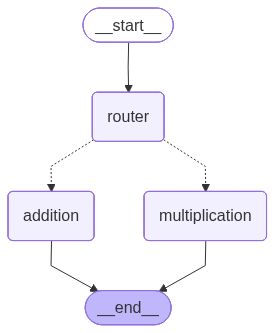

In [35]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [45]:
result1 = app.invoke({ "number1": 2, "number2": 4, "operator": "+"})

result1

{'number1': 2, 'operator': '+', 'number2': 4, 'final_number': 6}

In [44]:
result2 = app.invoke({ "number1": 2, "number2": 4, "operator": "*"})

result2

{'number1': 2, 'operator': '*', 'number2': 4, 'final_number': 8}